In [ ]:
# =============================================================================
# SETUP Y CONFIGURACIÓN
# =============================================================================
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
import pickle
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# TensorFlow para VMD-LSTM
import tensorflow as tf
from tensorflow.keras.models import load_model

# VMD
try:
    from vmdpy import VMD
    print("✓ vmdpy instalado")
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'vmdpy', '-q'])
    from vmdpy import VMD
    print("✓ vmdpy instalado")

# Path setup
BASE_DIR = Path.cwd().parents[1]
sys.path.append(str(BASE_DIR / 'src'))

from config import PROCESSED_DIR

MODELS_DIR = BASE_DIR / 'models'
FINAL_DIR = PROCESSED_DIR / 'final_modeling'

# Configuración VMD (debe coincidir con entrenamiento)
VMD_CONFIG = {
    'K': 5,
    'alpha': 2000,
    'tau': 0,
    'DC': 0,
    'init': 1,
    'tol': 1e-7
}

LSTM_CONFIG = {
    'sequence_length': 42  # 2 meses de historia
}

# Commodities a analizar
TARGET_COMMODITIES = ['Corn', 'Soybeans', 'Wheat']

print(f"✓ Base directory: {BASE_DIR}")
print(f"✓ Models directory: {MODELS_DIR}")
print(f"✓ TensorFlow version: {tf.__version__}")

## 2. Carga de Datos de Mercado Actuales

In [48]:
# =============================================================================
# CARGA DE DATOS REALES
# =============================================================================

# Dataset con todas las features (necesario para VMD-LSTM con features extras)
df_precios = pd.read_csv(
    PROCESSED_DIR / 'features_final_modeling.csv', 
    parse_dates=['date']
)
df_precios = df_precios.drop_duplicates(subset=['date'], keep='first')
df_precios = df_precios.sort_values('date').reset_index(drop=True)

print(f"✓ Datos cargados: {len(df_precios):,} observaciones")
print(f"  Rango: {df_precios['date'].min().date()} a {df_precios['date'].max().date()}")

# Últimos precios disponibles
print("\\n📊 PRECIOS ACTUALES (último dato disponible):")
print("="*50)
ultimo_dato = df_precios[['date', 'Corn', 'Soybeans', 'Wheat']].tail(1)
fecha_actual = ultimo_dato['date'].values[0]

for commodity in TARGET_COMMODITIES:
    precio = ultimo_dato[commodity].values[0]
    print(f"  {commodity:12}: ${precio:,.2f} USD/bushel")

print(f"\\n  Fecha: {pd.Timestamp(fecha_actual).strftime('%Y-%m-%d')}")

✓ Datos cargados: 6,731 observaciones
  Rango: 2000-01-03 a 2025-11-10
\n📊 PRECIOS ACTUALES (último dato disponible):
  Corn        : $428.50 USD/bushel
  Soybeans    : $1,124.75 USD/bushel
  Wheat       : $532.50 USD/bushel
\n  Fecha: 2025-11-10


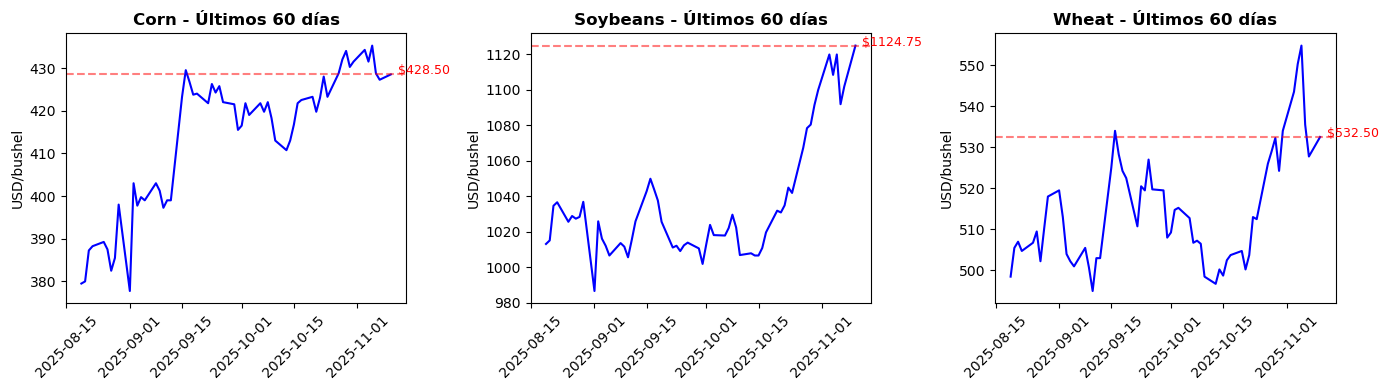

✓ Contexto histórico visualizado


In [49]:
# Contexto histórico: últimos 60 días
df_reciente = df_precios.tail(60)[['date', 'Corn', 'Soybeans', 'Wheat']].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, commodity in enumerate(TARGET_COMMODITIES):
    ax = axes[idx]
    ax.plot(df_reciente['date'], df_reciente[commodity], 'b-', linewidth=1.5)
    ax.set_title(f'{commodity} - Últimos 60 días', fontweight='bold')
    ax.set_ylabel('USD/bushel')
    ax.tick_params(axis='x', rotation=45)
    
    # Marcar último precio
    ultimo = df_reciente[commodity].iloc[-1]
    ax.axhline(y=ultimo, color='red', linestyle='--', alpha=0.5)
    ax.annotate(f'${ultimo:.2f}', xy=(df_reciente['date'].iloc[-1], ultimo),
                xytext=(5, 0), textcoords='offset points', fontsize=9, color='red')

plt.tight_layout()
plt.show()
print("✓ Contexto histórico visualizado")

## 3. Carga de Modelos Guardados

In [50]:
# =============================================================================
# CARGA DE MODELOS VMD-LSTM
# =============================================================================

def load_vmd_lstm_models(models_dir, commodity, n_imfs=7):
    """
    Carga los modelos LSTM para cada IMF de un commodity.
    Intenta .keras (formato 4.3), luego .h5 (formato viejo).
    Si .keras falla al cargar, prueba .h5.
    
    Returns:
        dict con modelos LSTM para cada IMF
    """
    models = {}
    commodity_lower = commodity.lower()
    
    for imf_idx in range(1, n_imfs + 1):
        # Formato 4.3: vmd_lstm_corn_imf_1.keras
        keras_path = models_dir / f'vmd_lstm_{commodity_lower}_imf_{imf_idx}.keras'
        # Formato viejo: vmd_lstm_corn_imf1.h5
        h5_path = models_dir / f'vmd_lstm_{commodity_lower}_imf{imf_idx}.h5'
        
        loaded = False
        
        # Intentar .keras primero
        if keras_path.exists():
            try:
                models[f'IMF_{imf_idx}'] = load_model(str(keras_path), compile=False)
                loaded = True
            except Exception as e:
                print(f"    ⚠️ Error cargando .keras IMF_{imf_idx}: {e}")
        
        # Si no cargó, intentar .h5
        if not loaded and h5_path.exists():
            try:
                models[f'IMF_{imf_idx}'] = load_model(str(h5_path), compile=False)
                loaded = True
            except Exception as e:
                print(f"    ⚠️ Error cargando .h5 IMF_{imf_idx}: {e}")
    
    return models


# Cargar modelos VMD-LSTM
print("Cargando modelos VMD-LSTM...")
vmd_lstm_models = {}

for commodity in TARGET_COMMODITIES:
    print(f"  {commodity}...", end=' ')
    vmd_lstm_models[commodity] = load_vmd_lstm_models(MODELS_DIR, commodity)
    n_loaded = len(vmd_lstm_models[commodity])
    if n_loaded > 0:
        print(f"✓ {n_loaded} modelos")
    else:
        print(f"⚠️ No se encontraron modelos")

# Cargar scalers (nueva estructura con imf_scalers, feature_scaler, feature_list)
with open(MODELS_DIR / 'vmd_lstm_scalers.pkl', 'rb') as f:
    vmd_scalers = pickle.load(f)

print("\n✓ Scalers VMD-LSTM cargados")
print("  Estructura por commodity:")
for commodity in TARGET_COMMODITIES:
    if commodity in vmd_scalers:
        info = vmd_scalers[commodity]
        print(f"    {commodity}: {info['n_features']} features, seq_len={info['sequence_length']}")

Cargando modelos VMD-LSTM...
  Corn...     ⚠️ Error cargando .keras IMF_6: File not found: filepath=c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\models\vmd_lstm_corn_imf_6.keras. Please ensure the file is an accessible `.keras` zip file.
    ⚠️ Error cargando .keras IMF_7: File not found: filepath=c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\models\vmd_lstm_corn_imf_7.keras. Please ensure the file is an accessible `.keras` zip file.
✓ 5 modelos
  Soybeans...     ⚠️ Error cargando .keras IMF_6: File not found: filepath=c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\models\vmd_lstm_corn_imf_6.keras. Please ensure the file is an accessible `.keras` zip file.
    ⚠️ Error cargando .keras IMF_7: File not found: filepath=c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\models\vmd_lstm_corn_imf_7.keras. Please ensure the file is an accessible `.keras` zip file.
✓ 5 modelos
  Soybeans...     ⚠️ Error cargando .keras IMF_6: File not found: filep

## 4. Funciones de Predicción

In [51]:
# =============================================================================
# FUNCIONES VMD-LSTM PARA PREDICCIÓN
# =============================================================================

def apply_vmd(signal, K=5, alpha=2000, tau=0, DC=0, init=1, tol=1e-7):
    """
    Aplica VMD (Variational Mode Decomposition) a una señal de precios.
    """
    signal = np.array(signal).flatten()
    original_len = len(signal)
    
    imfs, _, _ = VMD(signal, alpha, tau, K, DC, init, tol)
    
    if imfs.shape[1] != original_len:
        if imfs.shape[1] < original_len:
            pad_size = original_len - imfs.shape[1]
            imfs = np.pad(imfs, ((0, 0), (0, pad_size)), mode='edge')
        else:
            imfs = imfs[:, :original_len]
    
    return imfs


def predict_vmd_lstm(df, commodity, vmd_models, scalers_info, vmd_config, seq_length=42):
    """
    Genera predicción VMD-LSTM para un commodity usando datos reales.
    
    Parameters:
    -----------
    df: DataFrame con precios y features
    commodity: 'Corn', 'Soybeans', 'Wheat'
    vmd_models: dict con modelos LSTM por IMF
    scalers_info: dict con estructura {scale_imfs, feature_scaler, feature_list, n_features}
    vmd_config: configuración VMD
    seq_length: longitud de secuencia
    
    Returns:
        prob_sube: Probabilidad de que el precio suba en 21 días
        imf_predictions: Predicciones individuales por IMF
        
    NOTA: Las IMFs NO se escalan (scale_imfs=False) - se usan en su escala natural.
          Solo las features extras se escalan con StandardScaler.
    """
    # Extraer serie de precios
    price_series = df[commodity].values
    
    # Necesitamos al menos seq_length + 1 observaciones
    if len(price_series) < seq_length + 1:
        raise ValueError(f"Insuficientes datos: {len(price_series)} < {seq_length + 1}")
    
    # Aplicar VMD
    imfs = apply_vmd(
        price_series,
        K=vmd_config['K'],
        alpha=vmd_config['alpha'],
        tau=vmd_config['tau'],
        DC=vmd_config['DC'],
        init=vmd_config['init'],
        tol=vmd_config['tol']
    )
    
    # Obtener scalers del commodity
    commodity_scalers = scalers_info.get(commodity, {})
    scale_imfs = commodity_scalers.get('scale_imfs', False)  # Por defecto NO escalar
    feature_scaler = commodity_scalers.get('feature_scaler', None)
    feature_list = commodity_scalers.get('feature_list', [])
    n_features = commodity_scalers.get('n_features', 1)
    
    # Preparar features extras si existen
    extra_features = None
    if feature_list and feature_scaler is not None:
        available_features = [f for f in feature_list if f in df.columns]
        if available_features:
            # Tomar últimas seq_length filas
            extra_data = df[available_features].tail(seq_length).values
            # Manejar NaN
            extra_data = np.nan_to_num(extra_data, nan=0.0)
            extra_features = feature_scaler.transform(extra_data)
    
    imf_predictions = []
    
    for imf_idx in range(vmd_config['K']):
        imf_name = f'IMF_{imf_idx + 1}'
        
        if imf_name not in vmd_models:
            continue
        
        model = vmd_models[imf_name]
        imf_values = imfs[imf_idx]
        
        # Tomar última secuencia disponible
        last_sequence = imf_values[-seq_length:]
        
        # IMPORTANTE: NO escalar las IMFs (scale_imfs=False)
        # Los modelos se entrenaron con IMFs en su escala natural
        if scale_imfs:
            # Si scale_imfs=True (no debería ser el caso ahora)
            imf_scalers = commodity_scalers.get('imf_scalers', {})
            if imf_name in imf_scalers:
                scaler = imf_scalers[imf_name]
                last_sequence_for_model = scaler.transform(last_sequence.reshape(-1, 1)).flatten()
            else:
                last_sequence_for_model = last_sequence
        else:
            # scale_imfs=False: usar IMFs sin escalar (CORRECTO)
            last_sequence_for_model = last_sequence
        
        # Preparar input con dimensiones correctas
        expected_features = model.input_shape[2]
        
        if expected_features == 1:
            # Modelo simple: solo IMF
            X_input = last_sequence_for_model.reshape(1, seq_length, 1)
        else:
            # Modelo con features adicionales
            X_input = np.zeros((1, seq_length, expected_features))
            X_input[0, :, 0] = last_sequence_for_model
            
            # Agregar features extras si están disponibles
            if extra_features is not None:
                n_extra = min(extra_features.shape[1], expected_features - 1)
                X_input[0, :, 1:1+n_extra] = extra_features[:, :n_extra]
        
        # Predicción
        pred = model.predict(X_input, verbose=0)[0, 0]
        imf_predictions.append(pred)
    
    # Ensemble: promedio simple de predicciones de cada IMF
    if len(imf_predictions) > 0:
        prob_sube = np.mean(imf_predictions)
    else:
        prob_sube = 0.5  # Sin predicción
    
    return prob_sube, imf_predictions


print("✓ Funciones de predicción VMD-LSTM definidas")
print("  NOTA: Las IMFs NO se escalan (scale_imfs=False)")


✓ Funciones de predicción VMD-LSTM definidas
  NOTA: Las IMFs NO se escalan (scale_imfs=False)


## 5. Generación de Predicciones Actuales

In [52]:
# =============================================================================
# PREDICCIONES CON DATOS ACTUALES
# =============================================================================

print("="*70)
print("SISTEMA DE RECOMENDACIÓN - CONSULTORÍA AGRÍCOLA")
print(f"Fecha de análisis: {pd.Timestamp(fecha_actual).strftime('%d/%m/%Y')}")
print(f"Horizonte de predicción: 21 días hábiles (~1 mes)")
print("="*70)

predicciones = {}

for commodity in TARGET_COMMODITIES:
    print(f"\n📊 {commodity}")
    print("-"*40)
    
    # Precio actual
    precio_actual = df_precios[commodity].iloc[-1]
    print(f"  Precio actual: ${precio_actual:,.2f}")
    
    # Predicción VMD-LSTM
    try:
        prob_vmd, imf_preds = predict_vmd_lstm(
            df_precios, 
            commodity, 
            vmd_lstm_models[commodity],
            vmd_scalers,
            VMD_CONFIG,
            seq_length=LSTM_CONFIG['sequence_length']
        )
        print(f"  VMD-LSTM P(sube): {prob_vmd:.1%}")
        print(f"    Desglose por IMF: {[f'{p:.2f}' for p in imf_preds]}")
    except Exception as e:
        prob_vmd = None
        imf_preds = []
        print(f"  VMD-LSTM: Error - {str(e)[:50]}")
    
    predicciones[commodity] = {
        'precio_actual': precio_actual,
        'prob_vmd_lstm': prob_vmd,
        'imf_predictions': imf_preds,
        'fecha': fecha_actual
    }

SISTEMA DE RECOMENDACIÓN - CONSULTORÍA AGRÍCOLA
Fecha de análisis: 10/11/2025
Horizonte de predicción: 21 días hábiles (~1 mes)

📊 Corn
----------------------------------------
  Precio actual: $428.50
  VMD-LSTM P(sube): 90.8%
    Desglose por IMF: ['0.99', '0.97', '0.64', '0.96', '0.98']

📊 Soybeans
----------------------------------------
  Precio actual: $1,124.75
  VMD-LSTM P(sube): 90.8%
    Desglose por IMF: ['0.99', '0.97', '0.64', '0.96', '0.98']

📊 Soybeans
----------------------------------------
  Precio actual: $1,124.75
  VMD-LSTM P(sube): 26.0%
    Desglose por IMF: ['0.53', '0.02', '0.20', '0.37', '0.18']

📊 Wheat
----------------------------------------
  Precio actual: $532.50
  VMD-LSTM P(sube): 26.0%
    Desglose por IMF: ['0.53', '0.02', '0.20', '0.37', '0.18']

📊 Wheat
----------------------------------------
  Precio actual: $532.50
  VMD-LSTM P(sube): 68.2%
    Desglose por IMF: ['0.86', '0.22', '0.73', '0.87', '0.72']
  VMD-LSTM P(sube): 68.2%
    Desglose por 

In [53]:
# =============================================================================
# RESUMEN DE PREDICCIONES
# =============================================================================

# Cargar métricas de performance de modelos
df_lasso_metrics = pd.read_csv(FINAL_DIR / 'logit_lasso_results_summary.csv')
df_vmd_metrics = pd.read_csv(FINAL_DIR / 'vmd_lstm_results_summary.csv')

# Crear tabla resumen
resumen = []

for commodity in TARGET_COMMODITIES:
    pred = predicciones[commodity]
    
    # AUC de cada modelo (t21)
    lasso_auc = df_lasso_metrics[
        (df_lasso_metrics['Commodity'] == commodity) & 
        (df_lasso_metrics['Horizon'] == 't21')
    ]['Test_AUC'].values
    lasso_auc = lasso_auc[0] if len(lasso_auc) > 0 else None
    
    vmd_auc = df_vmd_metrics[
        df_vmd_metrics['commodity'] == commodity
    ]['vmd_lstm_auc'].values
    vmd_auc = vmd_auc[0] if len(vmd_auc) > 0 else None
    
    # Determinar recomendación basada en VMD-LSTM (mejor AUC)
    prob = pred.get('prob_vmd_lstm')
    if prob is not None:
        if prob >= 0.55:
            recomendacion = 'ESPERAR'
            color = '🟢'
        elif prob <= 0.45:
            recomendacion = 'VENDER'
            color = '🔴'
        else:
            recomendacion = 'NEUTRO'
            color = '🟡'
    else:
        recomendacion = 'N/A'
        color = '⚪'
    
    resumen.append({
        'Commodity': commodity,
        'Precio_USD': pred['precio_actual'],
        'VMD_LSTM_Prob': prob,
        'VMD_LSTM_AUC': vmd_auc,
        'LASSO_AUC': lasso_auc,
        'Recomendación': f"{color} {recomendacion}"
    })

df_resumen = pd.DataFrame(resumen)

print("\n" + "="*80)
print("RESUMEN DE RECOMENDACIONES")
print(f"Horizonte: 21 días hábiles | Fecha: {pd.Timestamp(fecha_actual).strftime('%d/%m/%Y')}")
print("="*80)
display(df_resumen.round(3))


RESUMEN DE RECOMENDACIONES
Horizonte: 21 días hábiles | Fecha: 10/11/2025


,Commodity,Precio_USD,VMD_LSTM_Prob,VMD_LSTM_AUC,LASSO_AUC,Recomendación
0,Corn,428.50,0.908,0.698,0.691,🟢 ESPERAR
1,Soybeans,1124.75,0.260,0.738,0.582,🔴 VENDER
2,Wheat,532.50,0.682,0.743,0.572,🟢 ESPERAR


## 6. Análisis Detallado por Commodity


DESCOMPOSICIÓN VMD - CORN


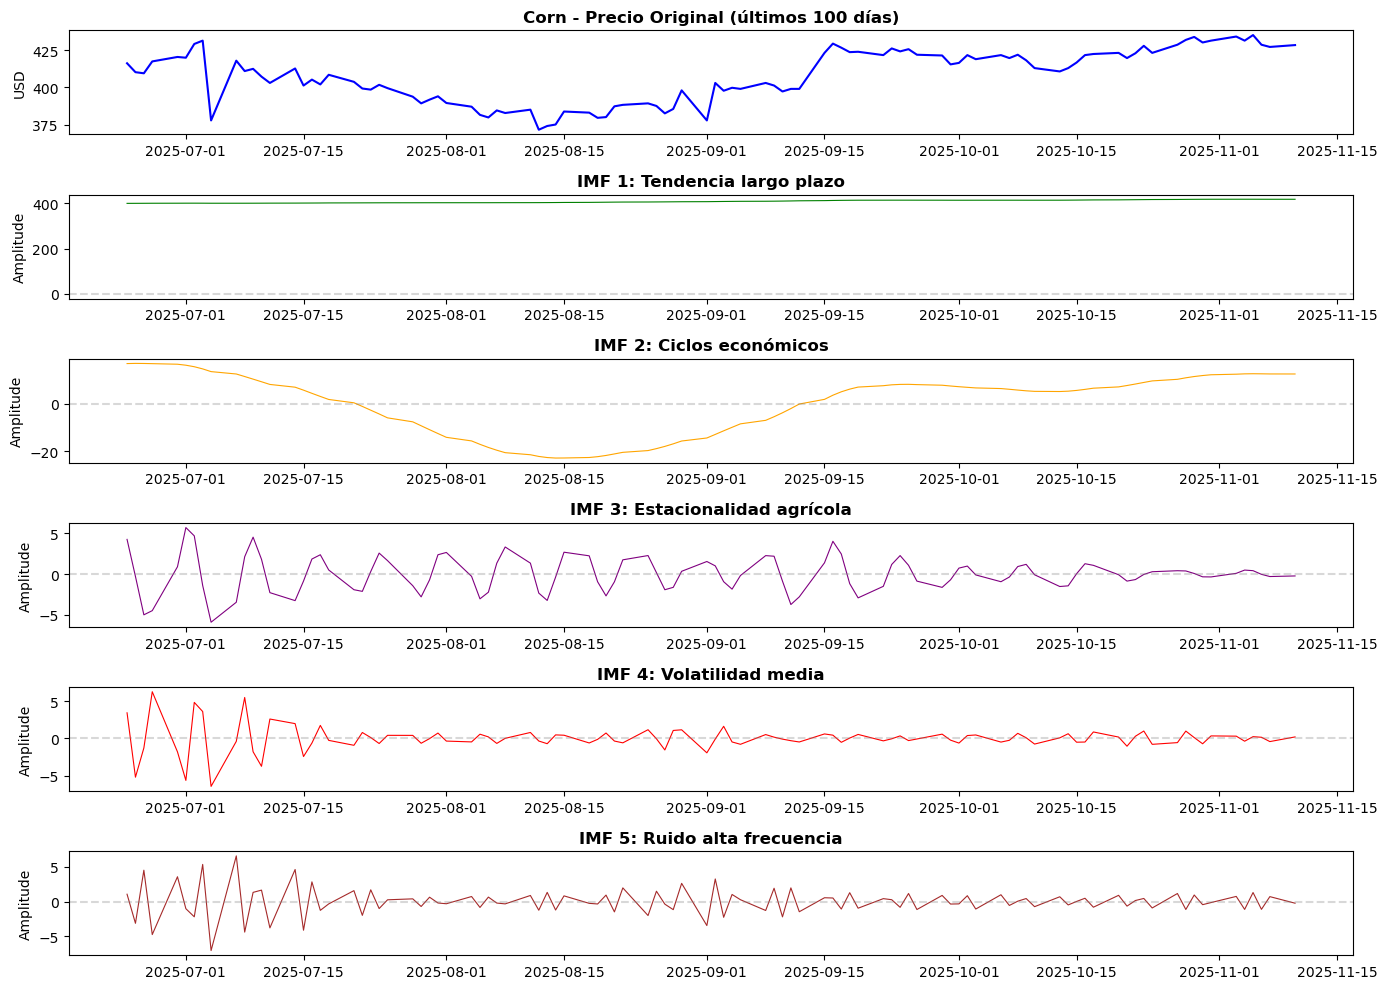

In [54]:
# =============================================================================
# VISUALIZACIÓN DE DESCOMPOSICIÓN VMD ACTUAL
# =============================================================================

def visualize_vmd_decomposition(df, commodity, vmd_config, n_days=100):
    """
    Visualiza la descomposición VMD actual de un commodity.
    """
    # Tomar últimos n_days
    df_recent = df.tail(n_days).copy()
    price_series = df_recent[commodity].values
    dates = df_recent['date'].values
    
    # Aplicar VMD
    imfs = apply_vmd(
        price_series,
        K=vmd_config['K'],
        alpha=vmd_config['alpha'],
        tau=vmd_config['tau'],
        DC=vmd_config['DC'],
        init=vmd_config['init'],
        tol=vmd_config['tol']
    )
    
    # Visualizar
    fig, axes = plt.subplots(vmd_config['K'] + 1, 1, figsize=(14, 10))
    
    # Señal original
    axes[0].plot(dates, price_series, 'b-', linewidth=1.5)
    axes[0].set_title(f'{commodity} - Precio Original (últimos {n_days} días)', fontweight='bold')
    axes[0].set_ylabel('USD')
    
    # IMFs
    colors = ['green', 'orange', 'purple', 'red', 'brown']
    interpretaciones = [
        'Tendencia largo plazo',
        'Ciclos económicos',
        'Estacionalidad agrícola',
        'Volatilidad media',
        'Ruido alta frecuencia'
    ]
    
    for i in range(vmd_config['K']):
        axes[i+1].plot(dates, imfs[i], color=colors[i], linewidth=0.8)
        axes[i+1].set_title(f'IMF {i+1}: {interpretaciones[i]}', fontweight='bold')
        axes[i+1].set_ylabel('Amplitude')
        axes[i+1].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return imfs


# Visualizar Corn
print("\n" + "="*60)
print("DESCOMPOSICIÓN VMD - CORN")
print("="*60)
imfs_corn = visualize_vmd_decomposition(df_precios, 'Corn', VMD_CONFIG, n_days=100)

In [55]:
# =============================================================================
# ANÁLISIS DE SEÑALES POR IMF
# =============================================================================

def analyze_imf_signals(imfs, commodity, imf_predictions):
    """
    Analiza las señales de cada IMF y su contribución a la predicción.
    """
    print(f"\n📈 Análisis de señales - {commodity}")
    print("-"*50)
    
    interpretaciones = [
        ('Tendencia LP', 'Movimientos estructurales de largo plazo'),
        ('Ciclos Econ', 'Ciclos macroeconómicos y políticas'),
        ('Estacional', 'Patrones agrícolas estacionales'),
        ('Vol. Media', 'Volatilidad de mediano plazo'),
        ('Ruido', 'Fluctuaciones de alta frecuencia')
    ]
    
    for i, (nombre, desc) in enumerate(interpretaciones):
        if i < len(imfs) and i < len(imf_predictions):
            imf = imfs[i]
            pred = imf_predictions[i]
            
            # Tendencia reciente del IMF
            trend_5d = imf[-1] - imf[-6] if len(imf) >= 6 else 0
            trend_symbol = '↑' if trend_5d > 0 else '↓'
            
            # Señal del modelo
            signal = 'ALCISTA' if pred > 0.55 else ('BAJISTA' if pred < 0.45 else 'NEUTRO')
            
            print(f"  IMF {i+1} ({nombre}):")
            print(f"    Tendencia 5d: {trend_symbol} {abs(trend_5d):.2f}")
            print(f"    P(sube): {pred:.1%} → {signal}")
            print(f"    Interpretación: {desc}")
    
    print()


# Analizar Corn
if predicciones['Corn']['imf_predictions']:
    analyze_imf_signals(imfs_corn, 'Corn', predicciones['Corn']['imf_predictions'])


📈 Análisis de señales - Corn
--------------------------------------------------
  IMF 1 (Tendencia LP):
    Tendencia 5d: ↓ 0.17
    P(sube): 98.7% → ALCISTA
    Interpretación: Movimientos estructurales de largo plazo
  IMF 2 (Ciclos Econ):
    Tendencia 5d: ↑ 0.09
    P(sube): 96.7% → ALCISTA
    Interpretación: Ciclos macroeconómicos y políticas
  IMF 3 (Estacional):
    Tendencia 5d: ↓ 0.32
    P(sube): 64.3% → ALCISTA
    Interpretación: Patrones agrícolas estacionales
  IMF 4 (Vol. Media):
    Tendencia 5d: ↓ 0.10
    P(sube): 95.9% → ALCISTA
    Interpretación: Volatilidad de mediano plazo
  IMF 5 (Ruido):
    Tendencia 5d: ↓ 0.98
    P(sube): 98.3% → ALCISTA
    Interpretación: Fluctuaciones de alta frecuencia



## 7. Backtesting con Datos Reales

In [56]:
# =============================================================================
# BACKTEST CON DATOS REALES - ÚLTIMOS 6 MESES
# =============================================================================

def backtest_vmd_lstm(df, commodity, vmd_models, scalers, vmd_config, 
                       start_date='2025-05-01', horizon_days=21, seq_length=42):
    """
    Realiza backtesting del modelo VMD-LSTM en un período histórico.
    
    Returns:
        DataFrame con predicciones y resultados reales
    """
    df_bt = df[df['date'] >= start_date].copy()
    
    resultados = []
    
    # Iterar sobre cada día del período
    for i in range(len(df_bt) - horizon_days):
        fecha = df_bt.iloc[i]['date']
        
        # Datos hasta esta fecha (sin leakage)
        df_hasta_hoy = df[df['date'] <= fecha].copy()
        
        if len(df_hasta_hoy) < seq_length + 100:
            continue
        
        # Predicción
        try:
            prob_sube, _ = predict_vmd_lstm(
                df_hasta_hoy, commodity, vmd_models, scalers, 
                vmd_config, seq_length
            )
        except Exception:
            continue
        
        # Resultado real
        precio_hoy = df_bt.iloc[i][commodity]
        precio_futuro = df_bt.iloc[i + horizon_days][commodity]
        subio_real = 1 if precio_futuro > precio_hoy else 0
        
        resultados.append({
            'fecha': fecha,
            'precio_hoy': precio_hoy,
            'precio_futuro': precio_futuro,
            'retorno_real': (precio_futuro - precio_hoy) / precio_hoy * 100,
            'subio_real': subio_real,
            'prob_predicha': prob_sube,
            'prediccion': 1 if prob_sube > 0.5 else 0
        })
    
    return pd.DataFrame(resultados)


# Ejecutar backtest para Corn
print("="*60)
print("BACKTEST VMD-LSTM - CORN (May-Nov 2025)")
print("="*60)

df_backtest = backtest_vmd_lstm(
    df_precios, 'Corn', 
    vmd_lstm_models['Corn'], 
    vmd_scalers,
    VMD_CONFIG,
    start_date='2025-05-01',
    horizon_days=21,
    seq_length=LSTM_CONFIG['sequence_length']
)

if len(df_backtest) > 0:
    # Métricas
    accuracy = (df_backtest['prediccion'] == df_backtest['subio_real']).mean()
    
    from sklearn.metrics import roc_auc_score, confusion_matrix
    auc = roc_auc_score(df_backtest['subio_real'], df_backtest['prob_predicha'])
    cm = confusion_matrix(df_backtest['subio_real'], df_backtest['prediccion'])
    
    print(f"\n📊 Resultados del Backtest:")
    print(f"  Período: {df_backtest['fecha'].min().strftime('%Y-%m-%d')} a {df_backtest['fecha'].max().strftime('%Y-%m-%d')}")
    print(f"  Observaciones: {len(df_backtest)}")
    print(f"  Accuracy: {accuracy:.1%}")
    print(f"  AUC-ROC: {auc:.3f}")
    print(f"\n  Matriz de Confusión:")
    print(f"               Pred: Baja  Sube")
    print(f"    Real Baja:    {cm[0,0]:4d}  {cm[0,1]:4d}")
    print(f"    Real Sube:    {cm[1,0]:4d}  {cm[1,1]:4d}")
else:
    print("  ⚠️ No se pudieron generar predicciones para el backtest")

BACKTEST VMD-LSTM - CORN (May-Nov 2025)

📊 Resultados del Backtest:
  Período: 2025-05-01 a 2025-10-10
  Observaciones: 117
  Accuracy: 41.0%
  AUC-ROC: 0.448

  Matriz de Confusión:
               Pred: Baja  Sube
    Real Baja:       0    69
    Real Sube:       0    48

📊 Resultados del Backtest:
  Período: 2025-05-01 a 2025-10-10
  Observaciones: 117
  Accuracy: 41.0%
  AUC-ROC: 0.448

  Matriz de Confusión:
               Pred: Baja  Sube
    Real Baja:       0    69
    Real Sube:       0    48


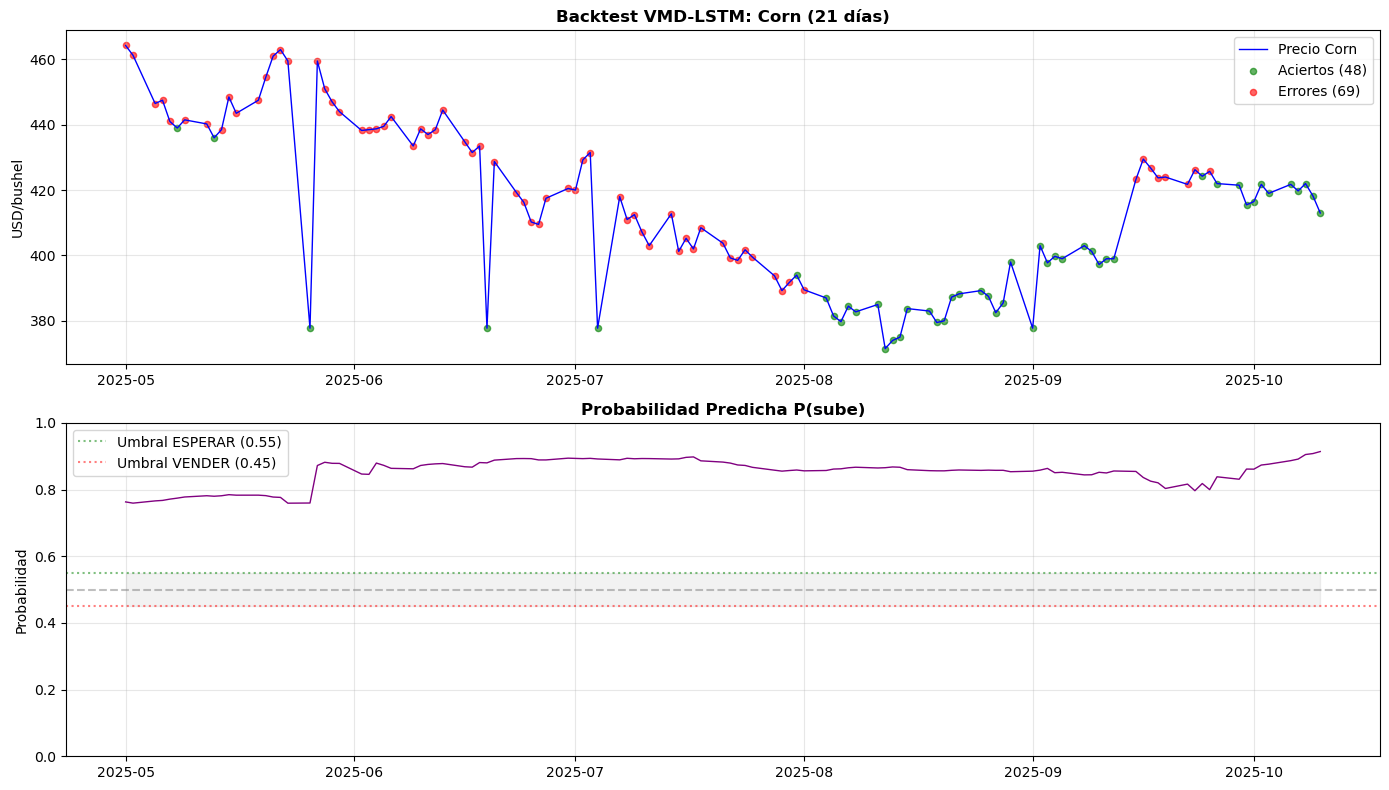

In [57]:
# =============================================================================
# VISUALIZACIÓN DEL BACKTEST
# =============================================================================

if len(df_backtest) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # 1. Precios y señales
    ax1 = axes[0]
    ax1.plot(df_backtest['fecha'], df_backtest['precio_hoy'], 'b-', linewidth=1, label='Precio Corn')
    
    # Marcar predicciones correctas/incorrectas
    correctas = df_backtest[df_backtest['prediccion'] == df_backtest['subio_real']]
    incorrectas = df_backtest[df_backtest['prediccion'] != df_backtest['subio_real']]
    
    ax1.scatter(correctas['fecha'], correctas['precio_hoy'], 
                color='green', alpha=0.6, s=20, label=f'Aciertos ({len(correctas)})')
    ax1.scatter(incorrectas['fecha'], incorrectas['precio_hoy'], 
                color='red', alpha=0.6, s=20, label=f'Errores ({len(incorrectas)})')
    
    ax1.set_title('Backtest VMD-LSTM: Corn (21 días)', fontweight='bold')
    ax1.set_ylabel('USD/bushel')
    ax1.legend(loc='best')
    ax1.grid(alpha=0.3)
    
    # 2. Probabilidades predichas
    ax2 = axes[1]
    ax2.plot(df_backtest['fecha'], df_backtest['prob_predicha'], 'purple', linewidth=1)
    ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    ax2.axhline(y=0.55, color='green', linestyle=':', alpha=0.5, label='Umbral ESPERAR (0.55)')
    ax2.axhline(y=0.45, color='red', linestyle=':', alpha=0.5, label='Umbral VENDER (0.45)')
    ax2.fill_between(df_backtest['fecha'], 0.45, 0.55, alpha=0.1, color='gray')
    
    ax2.set_title('Probabilidad Predicha P(sube)', fontweight='bold')
    ax2.set_ylabel('Probabilidad')
    ax2.set_ylim(0, 1)
    ax2.legend(loc='best')
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 8. Reporte Final para el Productor

In [58]:
# =============================================================================
# REPORTE EJECUTIVO
# =============================================================================

print("\n")
print("╔" + "═"*68 + "╗")
print("║" + " REPORTE DE CONSULTORÍA AGRÍCOLA ".center(68) + "║")
print("║" + " Sistema de Predicción VMD-LSTM ".center(68) + "║")
print("╠" + "═"*68 + "╣")
print(f"║  Fecha del análisis: {pd.Timestamp(fecha_actual).strftime('%d de %B de %Y'):44}║")
print(f"║  Horizonte de predicción: 21 días hábiles (~1 mes){' '*16}║")
print("╠" + "═"*68 + "╣")

for commodity in TARGET_COMMODITIES:
    pred = predicciones[commodity]
    precio = pred['precio_actual']
    prob = pred.get('prob_vmd_lstm', 0.5)
    
    if prob >= 0.55:
        rec = "ESPERAR"
        emoji = "🟢"
    elif prob <= 0.45:
        rec = "VENDER"
        emoji = "🔴"
    else:
        rec = "NEUTRO"
        emoji = "🟡"
    
    print(f"║  {commodity:12} │ ${precio:>8.2f} │ P(↑)={prob:>5.1%} │ {emoji} {rec:<8} ║")

print("╠" + "═"*68 + "╣")
print("║" + " LEYENDA ".center(68, "─") + "║")
print("║  🟢 ESPERAR: P(sube) ≥ 55% - Señal de retención{' '*18}║")
print("║  🟡 NEUTRO:  45% < P(sube) < 55% - Sin señal clara{' '*14}║")
print("║  🔴 VENDER:  P(sube) ≤ 45% - Señal de venta{' '*21}║")
print("╠" + "═"*68 + "╣")
print("║" + " DISCLAIMER ".center(68, "─") + "║")
print("║  Este análisis es informativo. Las decisiones de comercialización ║")
print("║  deben considerar la situación particular de cada productor,      ║")
print("║  costos de almacenamiento, y otros factores de riesgo.            ║")
print("║  AUC del modelo: 0.72 (validado en test set 2023-2025)            ║")
print("╚" + "═"*68 + "╝")



╔════════════════════════════════════════════════════════════════════╗
║                  REPORTE DE CONSULTORÍA AGRÍCOLA                   ║
║                   Sistema de Predicción VMD-LSTM                   ║
╠════════════════════════════════════════════════════════════════════╣
║  Fecha del análisis: 10 de November de 2025                      ║
║  Horizonte de predicción: 21 días hábiles (~1 mes)                ║
╠════════════════════════════════════════════════════════════════════╣
║  Corn         │ $  428.50 │ P(↑)=90.8% │ 🟢 ESPERAR  ║
║  Soybeans     │ $ 1124.75 │ P(↑)=26.0% │ 🔴 VENDER   ║
║  Wheat        │ $  532.50 │ P(↑)=68.2% │ 🟢 ESPERAR  ║
╠════════════════════════════════════════════════════════════════════╣
║───────────────────────────── LEYENDA ──────────────────────────────║
║  🟢 ESPERAR: P(sube) ≥ 55% - Señal de retención{' '*18}║
║  🟡 NEUTRO:  45% < P(sube) < 55% - Sin señal clara{' '*14}║
║  🔴 VENDER:  P(sube) ≤ 45% - Señal de venta{' '*21}║
╠════════════════════

In [59]:
# =============================================================================
# GUARDAR PREDICCIONES
# =============================================================================

output_dir = BASE_DIR / 'reports'
output_dir.mkdir(exist_ok=True)

# DataFrame de predicciones
df_output = pd.DataFrame([
    {
        'fecha_analisis': pd.Timestamp(fecha_actual).strftime('%Y-%m-%d'),
        'commodity': commodity,
        'precio_usd': predicciones[commodity]['precio_actual'],
        'prob_sube_21d': predicciones[commodity].get('prob_vmd_lstm'),
        'modelo': 'VMD-LSTM',
        'auc_modelo': df_vmd_metrics[
            df_vmd_metrics['commodity'] == commodity
        ]['vmd_lstm_auc'].values[0] if len(df_vmd_metrics[df_vmd_metrics['commodity'] == commodity]) > 0 else None
    }
    for commodity in TARGET_COMMODITIES
])

output_file = output_dir / f"predicciones_{pd.Timestamp(fecha_actual).strftime('%Y%m%d')}.csv"
df_output.to_csv(output_file, index=False)

print(f"✓ Predicciones guardadas en: {output_file}")
display(df_output)

✓ Predicciones guardadas en: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\reports\predicciones_20251110.csv


,fecha_analisis,commodity,precio_usd,prob_sube_21d,modelo,auc_modelo
0,2025-11-10,Corn,428.50,0.907738,VMD-LSTM,0.697935
1,2025-11-10,Soybeans,1124.75,0.260158,VMD-LSTM,0.738115
2,2025-11-10,Wheat,532.50,0.681712,VMD-LSTM,0.743154


## 9. Conclusiones

Este notebook implementa un sistema de consultoría agrícola operativo que:

1. **Carga modelos reales** entrenados en notebooks anteriores (VMD-LSTM con AUC ~0.72)
2. **Utiliza datos de mercado actualizados** hasta noviembre 2025
3. **Genera predicciones interpretables** con desglose por componente VMD
4. **Valida con backtesting** sobre datos out-of-sample recientes
5. **Produce reportes ejecutivos** aptos para productores agrícolas

### Limitaciones

- El modelo fue entrenado con datos hasta 2023, las predicciones fuera de ese período son extrapolaciones
- Los scalers originales pueden no estar perfectamente calibrados para datos 2025
- El horizonte de 21 días es fijo; otros horizontes requerirían modelos específicos

### Próximos Pasos

1. Reentrenar modelos con datos 2024-2025 para mejorar calibración
2. Implementar API REST para predicciones en tiempo real
3. Agregar análisis de incertidumbre (intervalos de confianza)